# 02 · Financial ratios

**Question.** How do profitability, leverage and liquidity compare across the universe, how is each ratio computed, and what does it mean when a ratio is N/A?

Read from PostgreSQL; ratios are recomputed here with the functions in `src/analytics/ratios.py` to show that the stored numbers are reproducible.

*FinSight is an analytics tool, not investment advice.*

## 1. Data

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from src.database import queries
from src.database.connection import get_engine
from src.formatting import format_crore, format_metric, format_pct

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})
ACCENT, GREY = "#1f4e79", "#8c8c8c"

with get_engine().connect() as conn:
    companies = queries.load_companies(conn)
    metrics = queries.load_metrics(conn)
    statements = queries.load_statements(conn)
    prices = queries.load_prices(conn)
    as_of = queries.load_latest_price_date(conn).iloc[0]["latest"]
firms = companies[companies["entity_type"] == "company"].reset_index(drop=True)
short = lambda t: t.replace(".NS", "")
print(f"{len(firms)} companies in {firms['sector_name'].nunique()} sectors | "
      f"{len(metrics):,} stored metric rows | prices to {as_of}")

25 companies in 5 sectors | 6,146 stored metric rows | prices to 2026-10-06


## 2. Method

Every ratio is a pure function of a wide statement table (one row per company and period, one column per line item) holding the figures **as reported**, in the company's reporting currency. The cell below rebuilds that table and recomputes four ratios, then compares them with what the pipeline stored.

In [2]:
from src.analytics import compute, ratios

wide = compute.wide_table(statements, "annual", "original_value")
recomputed = {"net_margin": ratios.net_margin(wide), "ebitda_margin": ratios.ebitda_margin(wide),
              "roe": ratios.roe(wide), "revenue_growth": ratios.revenue_growth(wide)}
stored = metrics[(metrics["period_type"] == "annual")].set_index(
    ["ticker", "period_end_date", "metric_name"])["value"]
rows = []
for name, series in recomputed.items():
    both = pd.DataFrame({"here": series, "stored": stored.xs(name, level="metric_name")}).dropna()
    rows.append({"metric": name, "values compared": len(both),
                 "max abs difference": (both["here"] - both["stored"]).abs().max()})
check = pd.DataFrame(rows)
print(check.to_string(index=False))
print("\nNote: the stored EBITDA margin is N/A for banks by rule even where the source has an "
      "'EBITDA' figure;\nthe comparison above only covers rows where the pipeline stored a value.")

        metric  values compared  max abs difference
    net_margin               99                 0.0
 ebitda_margin               79                 0.0
           roe               99                 0.0
revenue_growth               73                 0.0

Note: the stored EBITDA margin is N/A for banks by rule even where the source has an 'EBITDA' figure;
the comparison above only covers rows where the pipeline stored a value.


## 3. Results

### 3.1 Latest fiscal year, by company

In [3]:
from src.analytics import comps

names = ["revenue_growth", "gross_margin", "ebitda_margin", "net_margin", "roe", "roa",
         "debt_to_equity", "net_debt_to_ebitda", "current_ratio", "fcf_margin"]
latest = {n: comps.latest_rows(metrics, n, "annual").set_index("ticker") for n in names}
table = pd.DataFrame({n: latest[n]["value"].reindex(firms["ticker"]) for n in names})
table.index = [short(t) for t in table.index]
units = {n: ("pct" if n.endswith(("growth", "margin")) or n in ("roe", "roa") else
             "multiple" if n == "net_debt_to_ebitda" else "ratio") for n in names}
shown = pd.DataFrame({n: [format_metric(v, units[n]) for v in table[n]] for n in names},
                     index=table.index)
shown.insert(0, "sector", firms["sector_name"].str[:10].to_numpy())
shown

,sector,revenue_growth,gross_margin,ebitda_margin,net_margin,roe,roa,debt_to_equity,net_debt_to_ebitda,current_ratio,fcf_margin
TCS,Informatio,4.6%,45.1%,27.1%,18.4%,48.7%,28.8%,0.11,-0.4x,2.23,18.0%
INFY,Informatio,4.6%,30.2%,25.3%,16.4%,31.6%,19.6%,0.10,-0.5x,1.98,18.5%
HCLTECH,Informatio,11.2%,47.0%,21.0%,12.8%,23.0%,15.0%,0.07,-0.9x,2.22,14.3%
WIPRO,Informatio,4.0%,29.2%,22.7%,14.2%,15.4%,9.8%,0.23,-1.6x,2.05,14.4%
TECHM,Informatio,7.2%,28.2%,15.5%,8.5%,16.9%,10.3%,0.07,-0.7x,1.90,9.6%
HDFCBANK,Financials,4.7%,N/A,N/A,36.6%,8.9%,1.4%,N/A,N/A,N/A,N/A
ICICIBANK,Financials,9.1%,N/A,N/A,24.3%,16.0%,2.0%,N/A,N/A,N/A,N/A
AXISBANK,Financials,4.0%,N/A,N/A,30.0%,13.1%,1.5%,N/A,N/A,N/A,N/A
KOTAKBANK,Financials,-0.3%,N/A,N/A,25.4%,11.4%,2.0%,N/A,N/A,N/A,N/A
SBIN,Financials,9.2%,N/A,N/A,21.8%,15.4%,1.1%,N/A,N/A,N/A,N/A


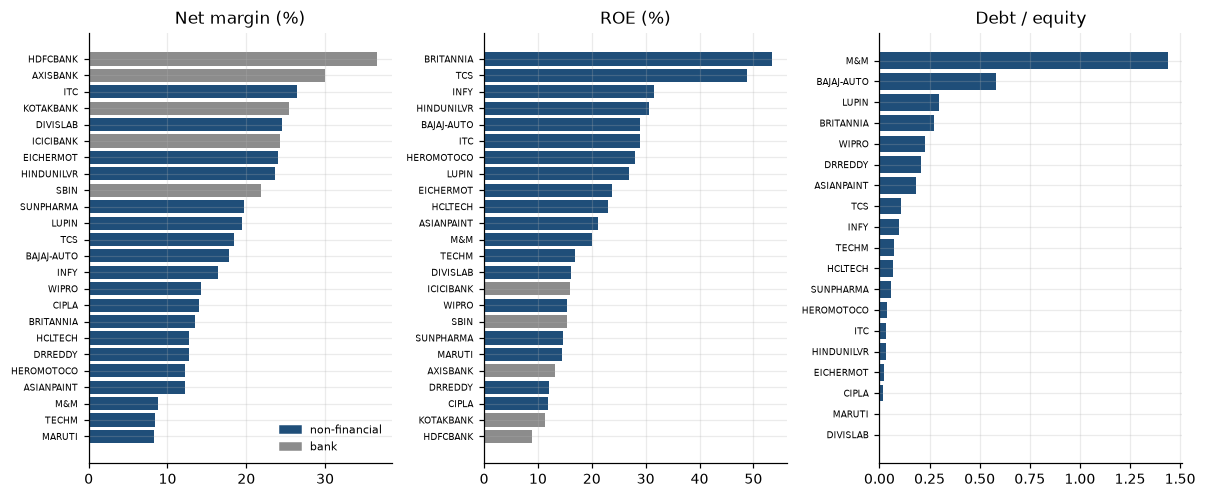

Sector medians (5 companies each; a median of N/A is N/A):
                        net_margin    roe  ebitda_margin  debt_to_equity
Auto                         0.122  0.238          0.214           0.036
Consumer                     0.185  0.298          0.227           0.108
Financials                   0.254  0.131            NaN             NaN
Information Technology       0.142  0.230          0.227           0.099
Pharmaceuticals              0.194  0.147          0.315           0.055

Debt/equity is shown for 19 companies: it is N/A for the banks, whose deposits are not debt.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4.6))
for ax, name, title in zip(axes, ("net_margin", "roe", "debt_to_equity"),
                           ("Net margin (%)", "ROE (%)", "Debt / equity")):
    values = table[name].dropna().sort_values()
    scale = 1 if name == "debt_to_equity" else 100
    sector = firms.set_index(firms["ticker"].map(short))["sector_type"]
    colours = [GREY if sector[t] == "bank" else ACCENT for t in values.index]
    ax.barh(values.index, values * scale, color=colours)
    ax.set_title(title); ax.tick_params(axis="y", labelsize=6)
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=ACCENT),
                        plt.Rectangle((0, 0), 1, 1, color=GREY)],
               labels=["non-financial", "bank"], frameon=False, fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()
by_sector = pd.DataFrame({n: table[n].groupby(firms["sector_name"].to_numpy()).median()
                          for n in ("net_margin", "roe", "ebitda_margin", "debt_to_equity")})
print("Sector medians (5 companies each; a median of N/A is N/A):")
print(by_sector.round(3).to_string())
print(f"\nDebt/equity is shown for {int(table['debt_to_equity'].notna().sum())} companies: it is "
      "N/A for the banks, whose deposits are not debt.")

### 3.2 What N/A means

A stored metric always has either a value or a reason.

In [5]:
annual = metrics[(metrics["period_type"] == "annual")
                 & metrics["ticker"].isin(firms["ticker"])].copy()    # sector_type is a column
annual["why"] = annual["na_reason"].str.replace(r":.*", "", regex=True)
reasons = (annual[annual["value"].isna()].groupby(["sector_type", "why"]).size()
           .rename("rows").reset_index())
print(reasons.to_string(index=False))
missing_both = int((annual["value"].isna() & annual["na_reason"].isna()).sum())
print(f"\nRows with neither a value nor a reason: {missing_both}")
bank = annual[(annual["sector_type"] == "bank") & annual["metric_name"].isin(
    ["ebitda_margin", "debt_to_equity", "current_ratio", "net_margin", "roe", "nii_growth",
     "loan_to_deposit"])]
print("\nBanks, annual rows:")
print(bank.groupby("metric_name").agg(rows=("value", "size"), with_value=("value", "count"),
                                      reason=("na_reason", "first")).to_string())

  sector_type                                              why  rows
         bank                   N/A (not meaningful for banks)   336
         bank                                input unavailable    53
         bank                     prior-year value unavailable    20
non_financial N/A (not meaningful for non-financial companies)   243
non_financial                                input unavailable    55
non_financial                  prior-year base is not positive     4
non_financial                     prior-year value unavailable   105

Rows with neither a value nor a reason: 0

Banks, annual rows:
                 rows  with_value                                             reason
metric_name                                                                         
current_ratio      21           0                     N/A (not meaningful for banks)
debt_to_equity     21           0                     N/A (not meaningful for banks)
ebitda_margin      21           0           

### 3.3 Two cases where the obvious calculation would be wrong

In [6]:
with get_engine().connect() as conn:
    infy = pd.read_sql(text("""
        SELECT f.fiscal_year, f.original_value / 1e6 AS revenue_usd_mn, f.fx_rate,
               f.value / 1e7 AS revenue_inr_cr
        FROM core.financial_statements f JOIN core.companies c USING (company_id)
        WHERE c.ticker = 'INFY.NS' AND f.line_item = 'revenue' AND f.period_type = 'annual'
          AND f.value IS NOT NULL ORDER BY 1"""), conn)
infy["growth in USD (stored)"] = infy["revenue_usd_mn"].pct_change()
infy["growth if measured in INR"] = infy["revenue_inr_cr"].pct_change()
print("Infosys reports in USD. Growth is computed in USD; INR figures are translations.")
print(infy.round(4).to_string(index=False))

eps = metrics[(metrics["ticker"] == "HDFCBANK.NS") & (metrics["metric_name"] == "eps")
              & (metrics["period_type"] == "annual") & metrics["value"].notna()]
hdfc = pd.DataFrame({
    "period": eps["period_end_date"].to_numpy(),
    "FinSight EPS": eps["value"].round(2).to_numpy(),
    "source EPS": [f.get("reported_eps_diluted") for f in eps["input_fields"]],
    "share restatement": [f.get("share_restatement") for f in eps["input_fields"]],
    "split factor": [f.get("split_factor") for f in eps["input_fields"]],
})
hdfc["FinSight growth"] = hdfc["FinSight EPS"].pct_change().round(4)
hdfc["source growth"] = hdfc["source EPS"].pct_change().round(4)
print("\nHDFC Bank issued a 1:1 bonus in August 2025. EPS on the current share basis:")
print(hdfc.to_string(index=False))

Infosys reports in USD. Growth is computed in USD; INR figures are translations.
 fiscal_year  revenue_usd_mn  fx_rate  revenue_inr_cr  growth in USD (stored)  growth if measured in INR
        2023         18212.0  80.3057     146252.7320                     NaN                        NaN
        2024         18562.0  82.7868     153668.8634                  0.0192                     0.0507
        2025         19277.0  84.5390     162965.8610                  0.0385                     0.0605
        2026         20158.0  88.3356     178066.9541                  0.0457                     0.0927

HDFC Bank issued a 1:1 bonus in August 2025. EPS on the current share basis:
    period  FinSight EPS  source EPS          share restatement  split factor  FinSight growth  source growth
2023-03-31         44.34       88.68       restated_by_finsight           2.0              NaN            NaN
2024-03-31         43.80       44.16       restated_by_finsight           2.0          -0.0122  

## 4. Interpretation

- The stored ratios are reproducible: recomputing them from the statement table with the same functions gives the same numbers (differences at floating-point level).
- Ratios differ by sector more than within it, and the sector medians above quantify by how much. Each median is five companies, so read them as a description of this universe.
- N/A is informative. For banks it mostly means *not meaningful* (EBITDA margin, debt/equity, liquidity ratios); elsewhere it means an input is missing or a growth rate has no positive base. No row lacks both a value and a reason.
- Two adjustments change the answer materially: measuring Infosys's growth in its reporting currency rather than in translated rupees, and putting HDFC Bank's share count on one basis so its bonus issue does not appear as a halving of EPS.

## 5. Limitations

- About four annual periods per company, so at most three growth observations each.
- ROE and ROA use average balances, with a closing-balance fallback for the earliest year (recorded in the `method` field).
- Bank-specific ratios (cost-to-income, loan/deposit) are N/A: the source provides neither operating expenses nor deposits.
- Nestle India has no income statement for FY2026 at source, so its latest-year ratios are N/A.
- One fiscal year is a snapshot; one-off items move single-year margins.

*FinSight is an analytics tool, not investment advice.*